In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup plotting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [16]:
# Load Dataset
train_path = r"C:\Users\yasse\OneDrive\Desktop\Mine All Ds\SatriaData26\case_1_labeled_data.xlsx - Sheet1.csv"
df_train = pd.read_csv(train_path)

print("INFO DATASET:")
print(df_train.info())
print("\nJUMLAH MISSING VALUES:")
print(df_train.isnull().sum())
print(f"\nJUMLAH DUPLIKAT: {df_train.duplicated().sum()}")

display(df_train.head())

INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  5000 non-null   object
 1   label      5000 non-null   object
dtypes: object(2)
memory usage: 78.3+ KB
None

JUMLAH MISSING VALUES:
full_text    0
label        0
dtype: int64

JUMLAH DUPLIKAT: 1


,full_text,label
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,Sasaran Penerima
1,MBG bentuk penggarongan duit negara secara TSM...,Politik
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,Sasaran Penerima
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,Sasaran Penerima
4,"@OniSuryaman Presiden ngotot, paling sebel kal...",Politik


C:\Users\yasse\AppData\Local\Temp\ipykernel_41340\190169030.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, y='label', order=order_kelas, palette='viridis')


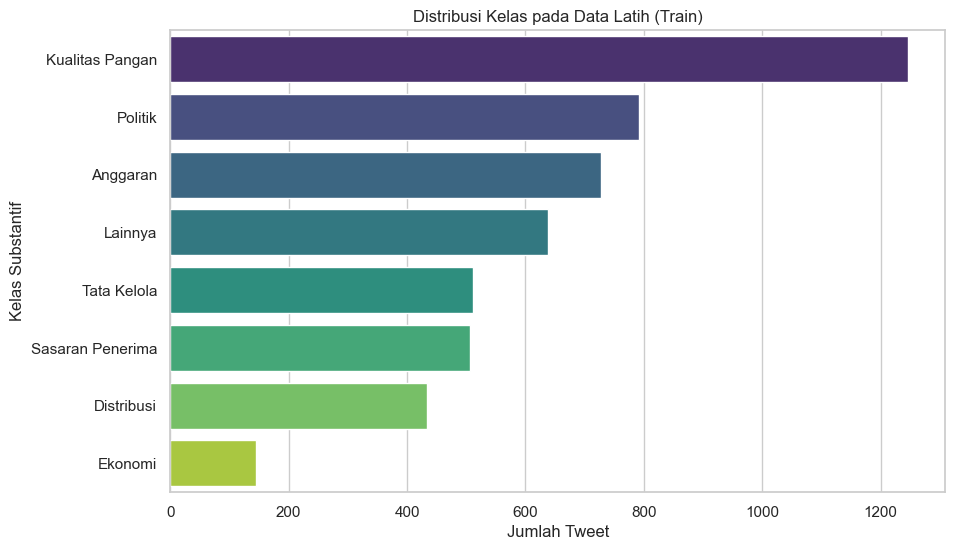

Persentase tiap kelas:
label
Kualitas Pangan     24.94
Politik             15.84
Anggaran            14.54
Lainnya             12.76
Tata Kelola         10.22
Sasaran Penerima    10.14
Distribusi           8.66
Ekonomi              2.90
Name: proportion, dtype: float64


In [17]:
# 1. Distribusi Kelas
plt.figure(figsize=(10, 6))
order_kelas = df_train['label'].value_counts().index
sns.countplot(data=df_train, y='label', order=order_kelas, palette='viridis')
plt.title("Distribusi Kelas pada Data Latih (Train)")
plt.xlabel("Jumlah Tweet")
plt.ylabel("Kelas Substantif")
plt.show()

# Tampilkan persentase tiap kelas
print("Persentase tiap kelas:")
print(df_train['label'].value_counts(normalize=True) * 100)

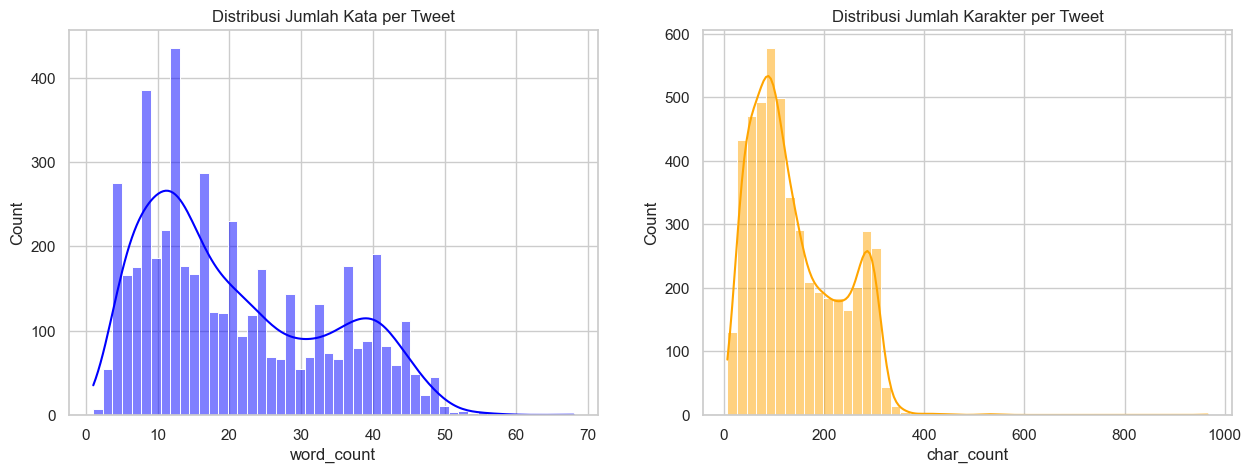

Rata-rata panjang kata: 20.75
Kata minimum: 1, Kata maksimum: 68


In [18]:
# 2. Distribusi Panjang Teks (Karakter & Kata)
df_train['word_count'] = df_train['full_text'].apply(lambda x: len(str(x).split()))
df_train['char_count'] = df_train['full_text'].apply(lambda x: len(str(x)))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_train['word_count'], bins=50, kde=True, ax=ax[0], color='blue')
ax[0].set_title("Distribusi Jumlah Kata per Tweet")

sns.histplot(df_train['char_count'], bins=50, kde=True, ax=ax[1], color='orange')
ax[1].set_title("Distribusi Jumlah Karakter per Tweet")
plt.show()

print(f"Rata-rata panjang kata: {df_train['word_count'].mean():.2f}")
print(f"Kata minimum: {df_train['word_count'].min()}, Kata maksimum: {df_train['word_count'].max()}")

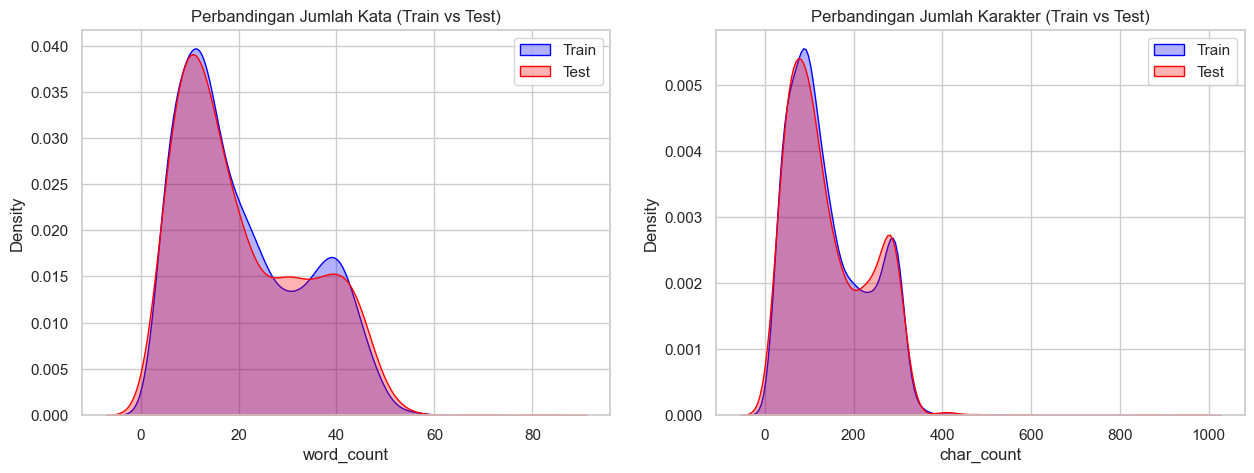

Data latih: 5000 tweets
Data uji: 1500 tweets


In [19]:
# 3. Load & Eksplorasi Data Uji (Test Data)
# Meskipun tidak ada label, kita visualisasikan karakteristik panjang teksnya vs Train
test_path = r"C:\Users\yasse\OneDrive\Desktop\Mine All Ds\SatriaData26\case_1_text_to_predict.xlsx - Sheet1.csv"
df_test = pd.read_csv(test_path)

df_test['word_count'] = df_test['full_text'].apply(lambda x: len(str(x).split()))
df_test['char_count'] = df_test['full_text'].apply(lambda x: len(str(x)))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# Perbandingan Distribusi
sns.kdeplot(df_train['word_count'], label='Train', ax=ax[0], color='blue', fill=True, alpha=0.3)
sns.kdeplot(df_test['word_count'], label='Test', ax=ax[0], color='red', fill=True, alpha=0.3)
ax[0].set_title("Perbandingan Jumlah Kata (Train vs Test)")
ax[0].legend()

sns.kdeplot(df_train['char_count'], label='Train', ax=ax[1], color='blue', fill=True, alpha=0.3)
sns.kdeplot(df_test['char_count'], label='Test', ax=ax[1], color='red', fill=True, alpha=0.3)
ax[1].set_title("Perbandingan Jumlah Karakter (Train vs Test)")
ax[1].legend()

plt.show()

print(f"Data latih: {len(df_train)} tweets")
print(f"Data uji: {len(df_test)} tweets")

### 4. Advanced EDA: Contrastive N-gram Analysis (Per Kelas)
Mencari kata/frasa khas (Bigram/Trigram) yang memiliki bobot TF-IDF tinggi secara eksklusif di masing-masing kelas.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import re

# Pastikan download stopwords bahasa Indonesia jika belum
try:
    stop_words = set(stopwords.words('indonesian'))
except:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('indonesian'))

def get_top_n_grams_by_class(df, text_col='full_text', label_col='label', n_gram_range=(2,3), top_n=10):
    classes = df[label_col].unique()
    tfidf = TfidfVectorizer(ngram_range=n_gram_range, stop_words=list(stop_words), max_features=5000)
    
    results = {}
    for cls in classes:
        corpus = df[df[label_col] == cls][text_col].dropna()
        if len(corpus) == 0: continue
            
        X = tfidf.fit_transform(corpus)
        features = tfidf.get_feature_names_out()
        scores = X.sum(axis=0).A1
        
        # Sort by score
        top_indices = scores.argsort()[::-1][:top_n]
        results[cls] = [(features[i], scores[i]) for i in top_indices]
        
    return results

# Tampilkan Top Bigram/Trigram per Kelas
top_ngrams = get_top_n_grams_by_class(df_train)
for cls, keywords in top_ngrams.items():
    print(f"\n[{cls}] Top N-grams:")
    for kw, score in keywords:
        print(f"  - {kw}: {score:.2f}")

C:\Users\yasse\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(



[Sasaran Penerima] Top N-grams:
  - https co: 22.89
  - makan bergizi: 15.44
  - bergizi gratis: 14.80
  - makan bergizi gratis: 14.70
  - program mbg: 12.94
  - program makan: 8.93
  - program makan bergizi: 8.84
  - anak anak: 7.55
  - juta penerima: 5.27
  - bergizi gratis mbg: 5.14

[Politik] Top N-grams:
  - https co: 19.86
  - makan bergizi: 15.53
  - program mbg: 15.11
  - bergizi gratis: 14.42
  - makan bergizi gratis: 14.42
  - program makan: 10.76
  - presiden prabowo: 9.08
  - program makan bergizi: 7.89
  - keracunan mbg: 7.22
  - sekolah rakyat: 6.58

[Kualitas Pangan] Top N-grams:
  - https co: 47.03
  - keracunan mbg: 28.36
  - mbg makan: 20.77
  - menu mbg: 18.69
  - makan mbg: 17.24
  - makan bergizi: 16.89
  - bergizi gratis: 16.82
  - makan bergizi gratis: 16.30
  - program mbg: 16.23
  - mbg nya: 15.00

[Distribusi] Top N-grams:
  - https co: 12.38
  - makan bergizi: 7.37
  - bergizi gratis: 7.26
  - makan bergizi gratis: 7.04
  - lanjutkan mbg: 6.69
  - program mb

### 5. Regex-Based Pattern Mining (Adversarial Detection)
Memetakan seberapa banyak data yang menggunakan bahasa gaul (slang) atau penulisan alay terkait Program MBG.

Persentase pola MBG Adversarial/Singkatan di Train Data:
93.00%

Persentase pola MBG Adversarial/Singkatan di Test Data:
93.20%


C:\Users\yasse\AppData\Local\Temp\ipykernel_41340\4244186402.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, y='label', x='has_mbg_slang', palette='magma')


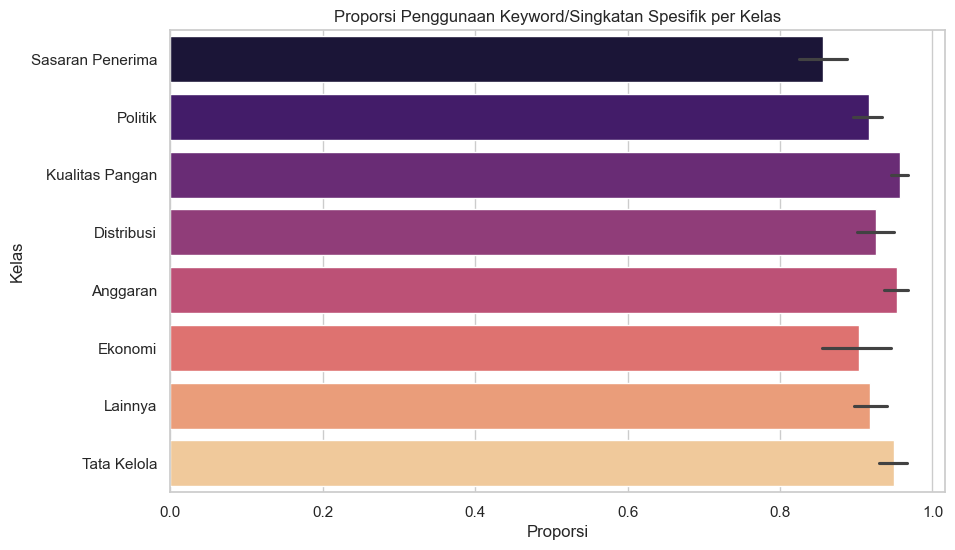

In [21]:
# Pola Regex untuk mendeteksi variasi penulisan "Makan Bergizi Gratis"
regex_pattern = r"m[a4]k[a4]n\s*gr[a4]t[i1]s|mbg|m[a4]k[a4]n\s*g[i1]z[i1]"

def detect_adversarial(text):
    if pd.isna(text): return 0
    return 1 if re.search(regex_pattern, text.lower()) else 0

df_train['has_mbg_slang'] = df_train['full_text'].apply(detect_adversarial)
df_test['has_mbg_slang'] = df_test['full_text'].apply(detect_adversarial)

print("Persentase pola MBG Adversarial/Singkatan di Train Data:")
print(f"{(df_train['has_mbg_slang'].mean() * 100):.2f}%")

print("\nPersentase pola MBG Adversarial/Singkatan di Test Data:")
print(f"{(df_test['has_mbg_slang'].mean() * 100):.2f}%")

# Lihat sebaran di setiap label
plt.figure(figsize=(10,6))
sns.barplot(data=df_train, y='label', x='has_mbg_slang', palette='magma')
plt.title("Proporsi Penggunaan Keyword/Singkatan Spesifik per Kelas")
plt.xlabel("Proporsi")
plt.ylabel("Kelas")
plt.show()

### 6. Semantic Co-occurrence & Class Overlap
Menemukan kata yang sering muncul bersamaan, serta mendeteksi ambiguitas (Overlap) antar kelas.

Menampilkan Network untuk kelas: Kualitas Pangan


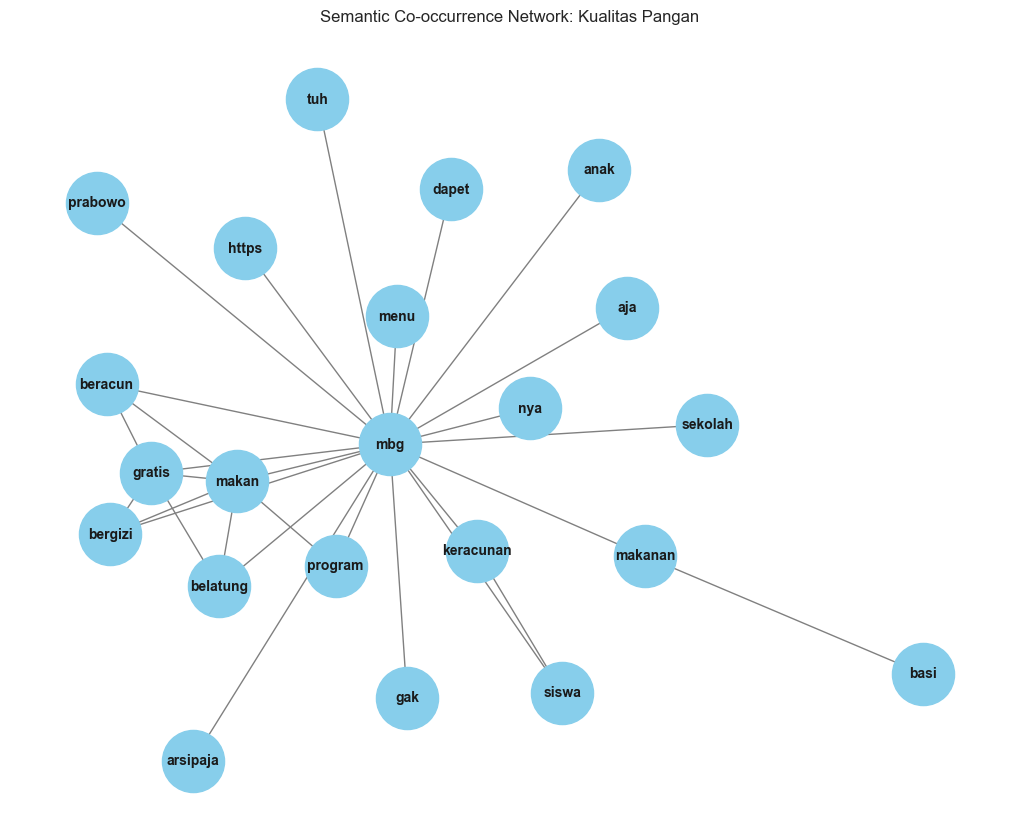

In [22]:
import networkx as nx
from itertools import combinations
from collections import Counter

def plot_cooccurrence_network(df, target_class, top_n=20, text_col='full_text'):
    corpus = df[df['label'] == target_class][text_col].dropna().tolist()
    
    # Tokenisasi sederhana
    tokens_list = []
    for text in corpus:
        tokens = [word for word in re.findall(r'\b\w+\b', text.lower()) if word not in stop_words and len(word) > 2]
        tokens_list.append(tokens)
        
    # Hitung Co-occurrence dalam rentang 3 kata (Jendela konteks)
    co_occurrences = Counter()
    for tokens in tokens_list:
        for i in range(len(tokens) - 2):
            window = tokens[i:i+3]
            for pair in combinations(set(window), 2):
                co_occurrences[tuple(sorted(pair))] += 1
                
    # Buat Graph
    G = nx.Graph()
    for (w1, w2), weight in co_occurrences.most_common(top_n):
        G.add_edge(w1, w2, weight=weight)
        
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, 
            font_size=10, font_weight='bold', edge_color='gray')
    plt.title(f"Semantic Co-occurrence Network: {target_class}")
    plt.show()

# Contoh visualisasi untuk kelas 'Anggaran' (Kamu bisa ganti dengan kelas lain)
# Asumsikan nama kelas anggaran ada, dicoba untuk kategori dengan frekuensi tinggi
top_class_sample = df_train['label'].value_counts().index[0]
print(f"Menampilkan Network untuk kelas: {top_class_sample}")
plot_cooccurrence_network(df_train, top_class_sample, top_n=30)

### 7. Analisis Kelas "Lainnya" (Noise Detection) & Metadata
Mengukur kepadatan tanda baca (Noise Density) dan identifikasi cuitan miskin makna (< 5 kata).

Persentase tweet pendek (< 5 kata) per kelas:
label
Lainnya             16.771160
Politik              2.525253
Kualitas Pangan      2.405774
Anggaran             1.100413
Distribusi           0.923788
Ekonomi              0.689655
Sasaran Penerima     0.591716
Tata Kelola          0.391389
Name: is_short, dtype: float64


C:\Users\yasse\AppData\Local\Temp\ipykernel_41340\1428135604.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='noise_density', y='label', palette='Set2')


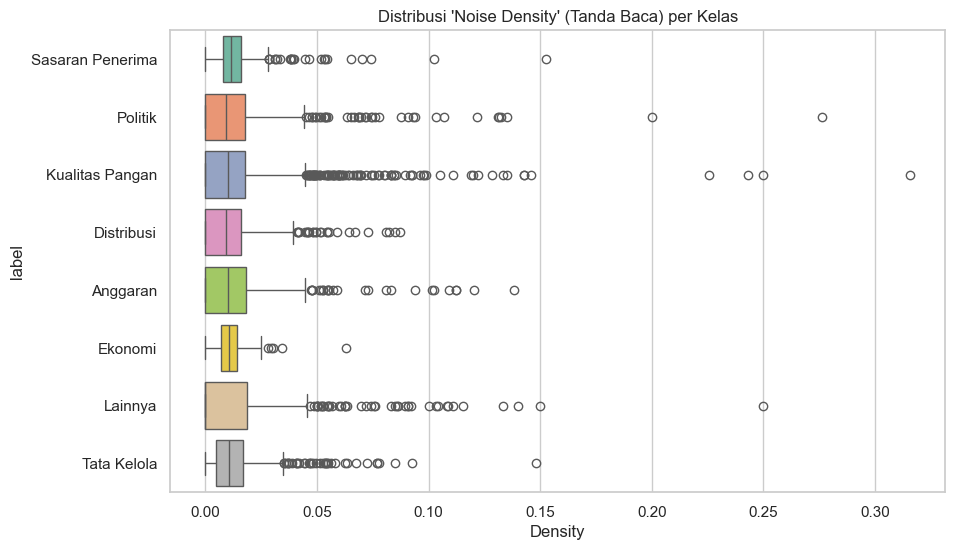

In [23]:
# 1. Analisis Cuitan Pendek (< 5 kata)
df_train['is_short'] = (df_train['word_count'] < 5).astype(int)
short_tweets_by_class = df_train.groupby('label')['is_short'].mean() * 100

print("Persentase tweet pendek (< 5 kata) per kelas:")
print(short_tweets_by_class.sort_values(ascending=False))

# 2. Noise Density (Tanda baca berlebihan)
def calculate_noise_density(text):
    if pd.isna(text): return 0
    punctuation_count = len(re.findall(r'[!?.]', text))
    return punctuation_count / (len(text) + 1)

df_train['noise_density'] = df_train['full_text'].apply(calculate_noise_density)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_train, x='noise_density', y='label', palette='Set2')
plt.title("Distribusi 'Noise Density' (Tanda Baca) per Kelas")
plt.xlabel("Density")
plt.show()

Analisis Similarity (Cosine Similarity pada TF-IDF)
Skrip ini memampatkan seluruh kata di Train dan Test menjadi dua dokumen besar, mengubahnya ke TF-IDF, lalu menghitung kesamaannya. Ini adalah indikator utama apakah Domain Shift terjadi.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Menggabungkan seluruh teks train menjadi 1 dokumen (korpus besar) dan test menjadi 1 dokumen
train_corpus = " ".join(df_train['full_text'].astype(str).tolist())
test_corpus = " ".join(df_test['full_text'].astype(str).tolist())

# Ekstraksi fitur TF-IDF, max_features membatasi untuk melihat core vocabulary
vectorizer = TfidfVectorizer(max_features=5000, stop_words=None) 
tfidf_matrix = vectorizer.fit_transform([train_corpus, test_corpus])

# Hitung kesamaan Cosine (Dokumen 0 = Train, Dokumen 1 = Test)
cos_sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

print(f"📊 Cosine Similarity antara Korpus Train & Test: {cos_sim:.4f}")

if cos_sim > 0.85:
    print("✅ Status: Sangat Representatif. Data Train mewakili hampir seluruh tantangan leksikal di Data Test.")
elif cos_sim > 0.70:
    print("⚠️ Status: Cukup Representatif. Terdapat pergeseran topik/istilah, pastikan model stabil dengan CV.")
else:
    print("🚨 Status: Domain Shift Tinggi! Data Test mengandung banyak OOV (Out-Of-Vocabulary) atau topik yang sama sekali tidak dibahas di Data Train.")


📊 Cosine Similarity antara Korpus Train & Test: 0.9954
✅ Status: Sangat Representatif. Data Train mewakili hampir seluruh tantangan leksikal di Data Test.


Deteksi Slang/Typo Khusus Entitas Program
Kode ini menggunakan Regex untuk mengumpulkan cara netizen X menulis "Makan Bergizi Gratis". Jika data Test punya slang baru (misal: maksi), kita wajib menambahkannya di Adversarial Normalization.

In [25]:
import re

def detect_mbg_variations(text_series):
    # Regex menangkap berbagai kemungkinan typo/slang
    pattern = r'\b(makan\s*gratis|makan\s*bergizi\s*gratis|makan\s*siang\s*gratis|mbg|msg|makan\s*siang|maksi|mkn\s*gratis|mkn\s*siang|gizi\s*gratis)\b'
    
    variations_found = {}
    for text in text_series:
        text_lower = str(text).lower()
        matches = re.findall(pattern, text_lower)
        for match in matches:
            # Hilangkan kelebihan spasi
            clean_match = " ".join(match.split())
            variations_found[clean_match] = variations_found.get(clean_match, 0) + 1
            
    # Urutkan dari frekuensi terbanyak
    return dict(sorted(variations_found.items(), key=lambda item: item[1], reverse=True))

train_variations = detect_mbg_variations(df_train['full_text'])
test_variations = detect_mbg_variations(df_test['full_text'])

print("🔥 Top 5 Variasi MBG - TRAIN:")
print(list(train_variations.items())[:5])
print("\n🔥 Top 5 Variasi MBG - TEST:")
print(list(test_variations.items())[:5])


🔥 Top 5 Variasi MBG - TRAIN:
[('mbg', 5153), ('makan bergizi gratis', 519), ('makan gratis', 58), ('makan siang', 20), ('makan siang gratis', 10)]

🔥 Top 5 Variasi MBG - TEST:
[('mbg', 1541), ('makan bergizi gratis', 146), ('makan gratis', 22), ('makan siang', 7), ('makan siang gratis', 6)]


Side-by-Side Visualization (Distribusi Train vs Test)
Modifikasi kode distribusi karakter dan kata untuk membandingkan df_train dan df_test secara langsung menggunakan parameter side-by-side di matplotlib.

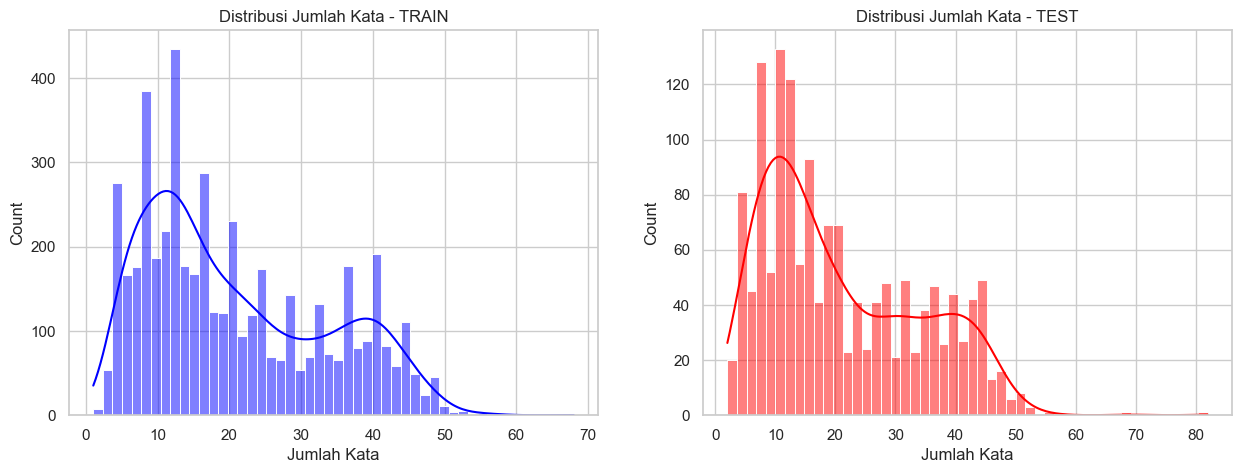

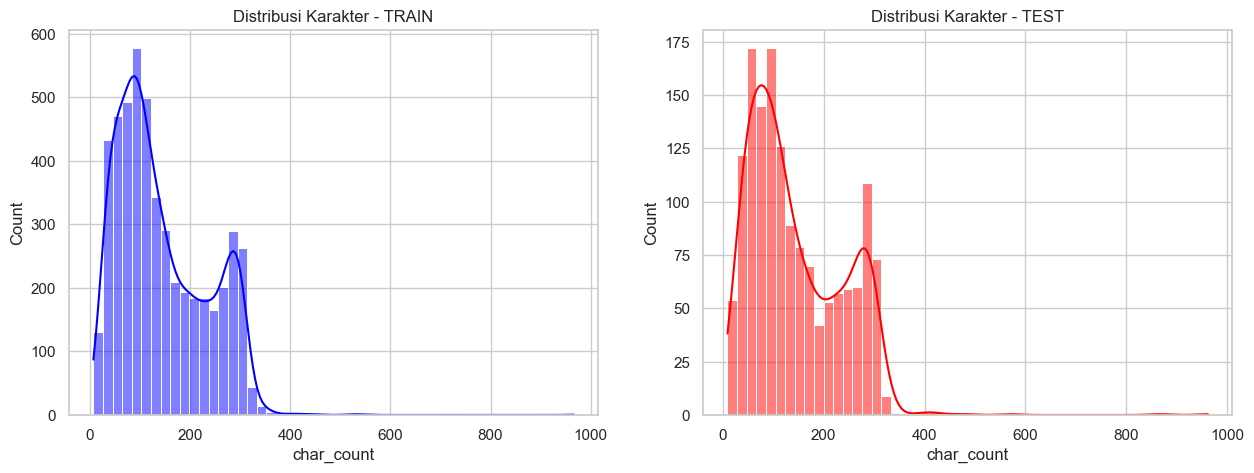

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data Test (Sesuaikan path-nya)
test_path = r"C:\Users\yasse\OneDrive\Desktop\Mine All Ds\SatriaData26\case_1_text_to_predict.xlsx - Sheet1.csv"
df_test = pd.read_csv(test_path)

# Hitung jumlah kata dan karakter untuk Test
df_test['word_count'] = df_test['full_text'].apply(lambda x: len(str(x).split()))
df_test['char_count'] = df_test['full_text'].apply(lambda x: len(str(x)))

# Plot Side-by-Side (Train vs Test) - Word Count
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_train['word_count'], bins=50, kde=True, ax=ax[0], color='blue')
ax[0].set_title("Distribusi Jumlah Kata - TRAIN")
ax[0].set_xlabel("Jumlah Kata")

sns.histplot(df_test['word_count'], bins=50, kde=True, ax=ax[1], color='red')
ax[1].set_title("Distribusi Jumlah Kata - TEST")
ax[1].set_xlabel("Jumlah Kata")
plt.show()

# Plot Side-by-Side (Train vs Test) - Char Count
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_train['char_count'], bins=50, kde=True, ax=ax[0], color='blue')
ax[0].set_title("Distribusi Karakter - TRAIN")

sns.histplot(df_test['char_count'], bins=50, kde=True, ax=ax[1], color='red')
ax[1].set_title("Distribusi Karakter - TEST")
plt.show()
